# 5 GHz + BLE + Power Offline Analysis

This notebook is the offline analysis counterpart to Grafana for the Monad fleet measurement plan. It reads normalized exports from `artifacts/analysis/<run_id>/`, computes thesis-ready statistics, and writes figures/tables back to `artifacts/figures/<run_id>/` and `artifacts/tables/<run_id>/`.

The first pass is intentionally tolerant of missing files. That lets us build the notebook before the pcap/Mimir/eLab export scripts are finished.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Configuration

Set `RUN_ID` to the folder name under `artifacts/analysis/`. The default points at the latest downloaded experiment-78 dataset. The notebook writes outputs under `artifacts/figures/<run_id>/` and `artifacts/tables/<run_id>/`.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").exists() and (candidate / "src").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root()
RUN_ID = "exp78-latest"

DATASET_DIR = REPO_ROOT / "artifacts" / "analysis" / RUN_ID
FIGURES_DIR = REPO_ROOT / "artifacts" / "figures" / RUN_ID
TABLES_DIR = REPO_ROOT / "artifacts" / "tables" / RUN_ID

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR

PosixPath('/Users/admin/FleetManager/artifacts/analysis/exp78-latest')

## Dataset Contract

Expected files in `DATASET_DIR`:

- `metadata.json`: run metadata such as `run_id`, `experiment_id`, profile, site, and device list.
- `events.ndjson`: agent run events, one JSON object per line.
- `wifi_5g_frames.csv`: one row per captured 802.11 frame after pcap extraction.
- `wifi_5g_channel_schedule.jsonl`: channel dwell log produced by the agent.
- `ble_tx.csv`: one row per BLE advertisement transmission ID.
- `ble_rx.csv`: one row per received BLE advertisement.
- `power_timeseries.csv`: one row per power telemetry sample.
- `command_status.csv`: normalized command outcome rows from evidence bundles.
- `wifi_capture_summary.csv`: per-Pi WIFI_SCAN outcome, including pcap byte count when reported.
- `dataset_summary.json`: preparation-level counts and caveats.

Current repo state can produce pcaps and channel schedules. The pcap-to-CSV extractor is the next implementation step after this notebook contract.

In [3]:
def read_json(path: Path, default=None):
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with path.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def coerce_time(df: pd.DataFrame, column: str = "timestamp") -> pd.DataFrame:
    if df.empty or column not in df.columns:
        return df
    out = df.copy()
    out[column] = pd.to_datetime(out[column], utc=True, errors="coerce")
    return out


def maybe_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def savefig(name: str):
    png = FIGURES_DIR / f"{name}.png"
    svg = FIGURES_DIR / f"{name}.svg"
    plt.savefig(png, dpi=180, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    return png, svg

In [4]:
metadata = read_json(DATASET_DIR / "metadata.json", default={}) or {}

events_path = DATASET_DIR / "events.ndjson"
if not events_path.exists():
    sample_events = REPO_ROOT / "artifacts" / "output" / "room_mock_216_events.ndjson"
    events_path = sample_events if sample_events.exists() else events_path

events = coerce_time(read_jsonl(events_path), "timestamp")
wifi = coerce_time(read_csv(DATASET_DIR / "wifi_5g_frames.csv"), "timestamp")
schedule = read_jsonl(DATASET_DIR / "wifi_5g_channel_schedule.jsonl")
ble_tx = coerce_time(read_csv(DATASET_DIR / "ble_tx.csv"), "tx_timestamp")
ble_rx = coerce_time(read_csv(DATASET_DIR / "ble_rx.csv"), "rx_timestamp")
power = coerce_time(read_csv(DATASET_DIR / "power_timeseries.csv"), "timestamp")
command_status = coerce_time(read_csv(DATASET_DIR / "command_status.csv"), "timestamp")
wifi_capture_summary = coerce_time(read_csv(DATASET_DIR / "wifi_capture_summary.csv"), "timestamp")
dataset_summary = read_json(DATASET_DIR / "dataset_summary.json", default={}) or {}

wifi = maybe_numeric(wifi, ["channel", "freq_mhz", "bandwidth_mhz", "frame_len", "rssi_dbm"])
schedule = maybe_numeric(schedule, ["channel", "dwell_start_us", "dwell_end_us"])
ble_rx = maybe_numeric(ble_rx, ["rssi_dbm"])
power = maybe_numeric(power, ["core_voltage_v", "pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "under_voltage", "cpu_temp_c"])

pd.DataFrame([
    {"stream": "events", "rows": len(events), "path": str(events_path.relative_to(REPO_ROOT)) if events_path.exists() else "missing"},
    {"stream": "wifi_5g_frames", "rows": len(wifi), "path": str((DATASET_DIR / "wifi_5g_frames.csv").relative_to(REPO_ROOT))},
    {"stream": "wifi_schedule", "rows": len(schedule), "path": str((DATASET_DIR / "wifi_5g_channel_schedule.jsonl").relative_to(REPO_ROOT))},
    {"stream": "ble_tx", "rows": len(ble_tx), "path": str((DATASET_DIR / "ble_tx.csv").relative_to(REPO_ROOT))},
    {"stream": "ble_rx", "rows": len(ble_rx), "path": str((DATASET_DIR / "ble_rx.csv").relative_to(REPO_ROOT))},
    {"stream": "power", "rows": len(power), "path": str((DATASET_DIR / "power_timeseries.csv").relative_to(REPO_ROOT))},
    {"stream": "command_status", "rows": len(command_status), "path": str((DATASET_DIR / "command_status.csv").relative_to(REPO_ROOT))},
    {"stream": "wifi_capture_summary", "rows": len(wifi_capture_summary), "path": str((DATASET_DIR / "wifi_capture_summary.csv").relative_to(REPO_ROOT))},
])

,stream,rows,path
0,events,6,artifacts/analysis/exp78-latest/events.ndjson
1,wifi_5g_frames,1216,artifacts/analysis/exp78-latest/wifi_5g_frames...
2,wifi_schedule,1642,artifacts/analysis/exp78-latest/wifi_5g_channe...
3,ble_tx,535,artifacts/analysis/exp78-latest/ble_tx.csv
4,ble_rx,0,artifacts/analysis/exp78-latest/ble_rx.csv
5,power,0,artifacts/analysis/exp78-latest/power_timeseri...
6,command_status,6,artifacts/analysis/exp78-latest/command_status...
7,wifi_capture_summary,2,artifacts/analysis/exp78-latest/wifi_capture_s...


## Sanity Checks

Before doing statistics, verify coverage and gaps. Gaps usually mean control-plane drops, agent restarts, or export problems.

In [5]:
def coverage_row(name: str, df: pd.DataFrame, ts_col: str = "timestamp") -> dict:
    row = {"stream": name, "rows": len(df), "start": pd.NaT, "end": pd.NaT, "duration_s": np.nan}
    if df.empty or ts_col not in df.columns:
        return row
    ts = pd.to_datetime(df[ts_col], utc=True, errors="coerce").dropna()
    if ts.empty:
        return row
    row["start"] = ts.min()
    row["end"] = ts.max()
    row["duration_s"] = (row["end"] - row["start"]).total_seconds()
    return row


if dataset_summary:
    display(dataset_summary)

coverage = pd.DataFrame([
    coverage_row("events", events),
    coverage_row("wifi", wifi),
    coverage_row("ble_tx", ble_tx, "tx_timestamp"),
    coverage_row("ble_rx", ble_rx, "rx_timestamp"),
    coverage_row("power", power),
])
coverage.to_csv(TABLES_DIR / "coverage.csv", index=False)
coverage

{'ble': {'rx_rows': 0,
  'rx_rows_by_pi': {},
  'rx_rows_with_adv_id': 0,
  'rx_rows_with_rssi': 0,
  'tx_rows': 535},
 'command_status_by_command_exit': {'ble-advertise-monad-02-10m|exit_0': 1,
  'ble-listen-monad-04-10m|exit_0': 1,
  'shell-rf-02-03-04-10m|exit_0': 2,
  'wifi-scan-monad-02-10m|exit_0': 1,
  'wifi-scan-monad-04-10m|exit_0': 1},
 'pcaps': {'inputs': 2, 'tshark_available': False},
 'wifi_capture_summary': [{'channels': '',
   'command_id': 'wifi-scan-monad-02-10m',
   'duration_ms': '0',
   'dwell_changes': '',
   'exit_code': '0',
   'message': 'passive_monitor started async',
   'pcap_bytes': '',
   'pi_id': 'monad-02',
   'run_id': '30805a6f-9501-4736-bbda-f5365beca26a',
   'source': 'run-30805a6f__report-replay__ag-e36a07__wireless-run-evidence-bundle__fcdc4bea.tar.gz',
   'timestamp': '2026-05-13T23:03:59.202072Z'},
  {'channels': '',
   'command_id': 'wifi-scan-monad-04-10m',
   'duration_ms': '0',
   'dwell_changes': '',
   'exit_code': '0',
   'message': 'passiv

,stream,rows,start,end,duration_s
0,events,6,2026-05-13 23:03:53.364724+00:00,2026-05-13 23:13:01.310852+00:00,5.479461e+02
1,wifi,1216,1970-01-01 00:08:19.537243+00:00,2026-05-13 23:12:53.423666+00:00,1.778713e+09
2,ble_tx,535,2026-05-13 23:04:03.374831+00:00,2026-05-13 23:12:57.734685+00:00,5.343599e+02
3,ble_rx,0,NaT,NaT,NaN
4,power,0,NaT,NaT,NaN


In [6]:
def gap_summary(df: pd.DataFrame, ts_col: str, group_col: str | None = None, threshold_s: float = 5.0) -> pd.DataFrame:
    if df.empty or ts_col not in df.columns:
        return pd.DataFrame(columns=["group", "gap_count", "max_gap_s"])
    work = df.copy()
    work[ts_col] = pd.to_datetime(work[ts_col], utc=True, errors="coerce")
    work = work.dropna(subset=[ts_col]).sort_values(ts_col)
    if group_col and group_col in work.columns:
        groups = work.groupby(group_col, dropna=False)
    else:
        groups = [("all", work)]
    rows = []
    for name, part in groups:
        gaps = part[ts_col].diff().dt.total_seconds().dropna()
        rows.append({"group": name, "gap_count": int((gaps > threshold_s).sum()), "max_gap_s": float(gaps.max()) if len(gaps) else 0.0})
    return pd.DataFrame(rows).sort_values(["gap_count", "max_gap_s"], ascending=False)


power_gaps = gap_summary(power, "timestamp", "pi_id", threshold_s=3.0)
wifi_gaps = gap_summary(wifi, "timestamp", "pi_id", threshold_s=3.0)
display(power_gaps.head(10))
display(wifi_gaps.head(10))

,group,gap_count,max_gap_s


,group,gap_count,max_gap_s
0,monad-02,73,1.778712e+09


## 5 GHz Statistics

These cells compute the exact aggregations requested in the plan once `wifi_5g_frames.csv` exists.

In [7]:
wifi_summary = {}

if not wifi_capture_summary.empty:
    display(wifi_capture_summary)

if wifi.empty:
    print("No wifi_5g_frames.csv yet. Next implementation step: pcap -> normalized CSV extractor using tshark.")
else:
    src_col = "src_mac" if "src_mac" in wifi.columns else None
    wifi_summary["wifi_frame_count"] = int(len(wifi))
    wifi_summary["wifi_distinct_src_macs"] = int(wifi[src_col].nunique()) if src_col else 0
    wifi_summary["wifi_distinct_bssids"] = int(wifi["bssid"].nunique()) if "bssid" in wifi.columns else 0
    wifi_summary["wifi_channels_seen"] = int(wifi["channel"].nunique()) if "channel" in wifi.columns else 0
    pd.Series(wifi_summary)

,timestamp,run_id,pi_id,command_id,exit_code,duration_ms,pcap_bytes,dwell_changes,channels,message,source
0,2026-05-13 23:03:59.202072+00:00,30805a6f-9501-4736-bbda-f5365beca26a,monad-02,wifi-scan-monad-02-10m,0,0,NaN,NaN,NaN,passive_monitor started async,run-30805a6f__report-replay__ag-e36a07__wirele...
1,2026-05-13 23:08:11.873070+00:00,f28b4512-7c60-4c33-aecd-267da8b07f6f,monad-04,wifi-scan-monad-04-10m,0,0,NaN,NaN,NaN,passive_monitor started async,run-f28b4512__report-replay__ag-80f4bf__wirele...


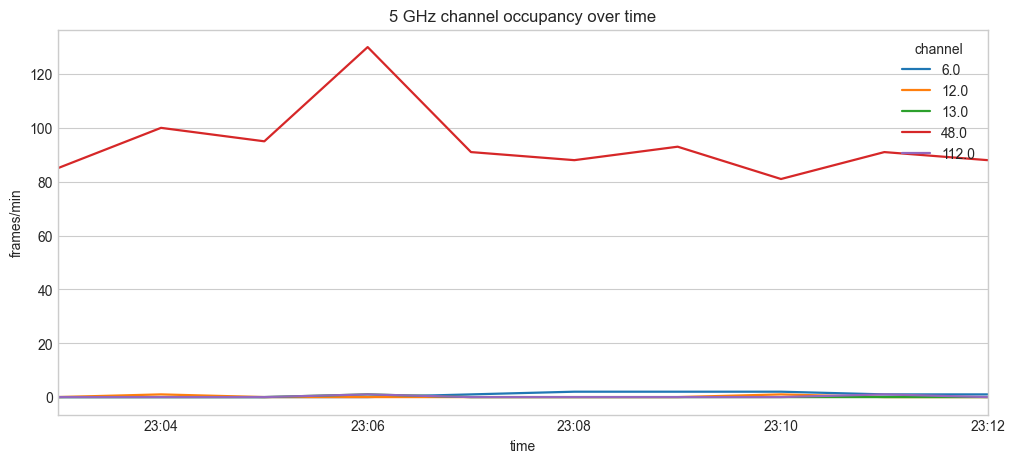

In [8]:
if not wifi.empty and {"channel", "timestamp"}.issubset(wifi.columns):
    work = wifi.dropna(subset=["timestamp", "channel"]).copy()
    work["minute"] = work["timestamp"].dt.floor("min")
    channel_timeline = work.groupby(["minute", "channel"]).size().rename("frames").reset_index()
    channel_pivot = channel_timeline.pivot(index="minute", columns="channel", values="frames").fillna(0)
    channel_pivot.to_csv(TABLES_DIR / "wifi_channel_occupancy_timeline.csv")
    ax = channel_pivot.plot(figsize=(12, 5), linewidth=1.6)
    ax.set_title("5 GHz channel occupancy over time")
    ax.set_xlabel("time")
    ax.set_ylabel("frames/min")
    savefig("wifi_channel_occupancy")
else:
    print("Skipping channel occupancy plot until timestamp + channel columns are available.")

In [9]:
if not wifi.empty and "src_oui" in wifi.columns:
    vendor_counts = wifi.groupby("src_oui", dropna=False)["src_mac"].nunique().rename("distinct_devices").reset_index()
    vendor_counts = vendor_counts.sort_values("distinct_devices", ascending=False)
    vendor_counts.to_csv(TABLES_DIR / "wifi_vendor_counts.csv", index=False)
    intel_devices = vendor_counts[vendor_counts["src_oui"].astype(str).str.contains("intel", case=False, na=False)]["distinct_devices"].sum()
    total_devices = max(1, vendor_counts["distinct_devices"].sum())
    wifi_summary["wifi_percent_intel"] = float(100.0 * intel_devices / total_devices)
    display(vendor_counts.head(20))
else:
    print("Skipping OUI/vendor breakdown until src_oui is available.")

,src_oui,distinct_devices
0,10:FE:ED,2
5,4C:CF:7C,2
1,24:EB:16,1
2,32:B4:FB,1
3,34:2C:C4,1
4,36:DF:92,1
6,AC:F8:CC,1
7,BE:7D:A0,1
8,FE:5C:22,1


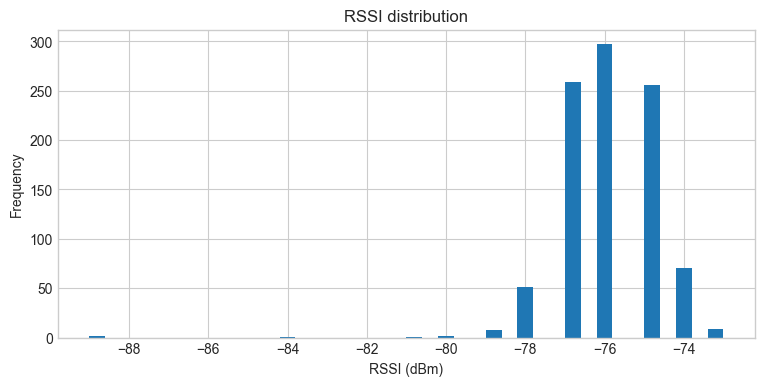

In [10]:
if not wifi.empty and "rssi_dbm" in wifi.columns:
    ax = wifi["rssi_dbm"].dropna().plot(kind="hist", bins=40, figsize=(9, 4))
    ax.set_title("RSSI distribution")
    ax.set_xlabel("RSSI (dBm)")
    savefig("wifi_rssi_distribution")
else:
    print("Skipping RSSI distribution until rssi_dbm is available.")

,frame_type,frames
0,data,1113
1,mgmt,103


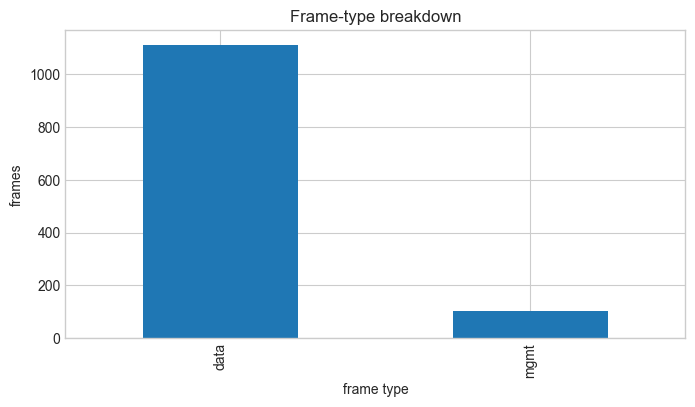

In [11]:
if not wifi.empty and "frame_type" in wifi.columns:
    frame_types = wifi["frame_type"].value_counts(dropna=False).rename_axis("frame_type").reset_index(name="frames")
    frame_types.to_csv(TABLES_DIR / "wifi_frame_type_breakdown.csv", index=False)
    ax = frame_types.plot(kind="bar", x="frame_type", y="frames", legend=False, figsize=(8, 4))
    ax.set_title("Frame-type breakdown")
    ax.set_xlabel("frame type")
    ax.set_ylabel("frames")
    savefig("wifi_frame_type_breakdown")
    display(frame_types)
else:
    print("Skipping frame-type breakdown until frame_type is available.")

In [12]:
if not wifi.empty and {"bssid", "ssid", "channel"}.issubset(wifi.columns):
    ap_inventory = (
        wifi.dropna(subset=["bssid"])
        .groupby(["bssid", "ssid", "channel"], dropna=False)
        .agg(frames=("bssid", "size"), median_rssi_dbm=("rssi_dbm", "median") if "rssi_dbm" in wifi.columns else ("bssid", "size"))
        .reset_index()
        .sort_values("frames", ascending=False)
    )
    ap_inventory.to_csv(TABLES_DIR / "wifi_ap_inventory.csv", index=False)
    display(ap_inventory.head(30))
else:
    print("Skipping AP inventory until bssid + ssid + channel columns are available.")

,bssid,ssid,channel,frames,median_rssi_dbm
2,10:fe:ed:3b:28:10,NaN,48.0,942,-76.0
3,10:fe:ed:3b:28:10,NaN,NaN,260,NaN
4,4c:cf:7c:26:76:b0,NaN,6.0,9,-75.0
0,10:fe:ed:3b:28:0f,NaN,12.0,2,-82.5
5,ac:f8:cc:07:93:65,NaN,112.0,2,-89.0
1,10:fe:ed:3b:28:0f,NaN,13.0,1,-77.0


## BLE Statistics

The main join key is `adv_id`: one transmitter event can have multiple receiver events from different Pis.

In [13]:
ble_summary = {}

if ble_tx.empty and ble_rx.empty:
    print("No BLE tx/rx CSVs yet. Scenario B tx logs already exist in the agent; phone/Pi receiver export still needs normalization.")
elif "adv_id" not in ble_rx.columns:
    print("BLE receiver data must include adv_id before cross-correlation is possible.")
else:
    ble_summary["ble_rx_count"] = int(len(ble_rx))
    ble_summary["ble_distinct_adv_ids_rx"] = int(ble_rx["adv_id"].nunique())
    if not ble_tx.empty and "adv_id" in ble_tx.columns:
        joined = ble_rx.merge(ble_tx, on="adv_id", how="left", suffixes=("_rx", "_tx"))
        if {"rx_timestamp", "tx_timestamp"}.issubset(joined.columns):
            joined["rx_timestamp"] = pd.to_datetime(joined["rx_timestamp"], utc=True, errors="coerce")
            joined["tx_timestamp"] = pd.to_datetime(joined["tx_timestamp"], utc=True, errors="coerce")
            joined["rx_minus_tx_ms"] = (joined["rx_timestamp"] - joined["tx_timestamp"]).dt.total_seconds() * 1000.0
        joined.to_csv(TABLES_DIR / "ble_joined_tx_rx.csv", index=False)
        display(joined.head(20))
    display(pd.Series(ble_summary))

,adv_id,rx_timestamp,rx_pi_id,device_mac,device_name,rssi_dbm,event_type,event_index,source_rx,tx_timestamp,tx_pi_id,seq,monotonic_us,source_tx,rx_minus_tx_ms


ble_rx_count               0
ble_distinct_adv_ids_rx    0
dtype: int64

In [14]:
TX_POWER_AT_1M_DBM = -59.0
PATH_LOSS_EXPONENT = 2.0

if not ble_rx.empty and "rssi_dbm" in ble_rx.columns:
    ble_rx_dist = ble_rx.copy()
    ble_rx_dist["distance_m_est"] = 10 ** ((TX_POWER_AT_1M_DBM - ble_rx_dist["rssi_dbm"]) / (10 * PATH_LOSS_EXPONENT))
    ble_rx_dist.to_csv(TABLES_DIR / "ble_rssi_distance_estimates.csv", index=False)
    ax = ble_rx_dist["distance_m_est"].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=30, figsize=(8, 4))
    ax.set_title("BLE RSSI-derived distance estimate")
    ax.set_xlabel("estimated distance (m)")
    savefig("ble_distance_estimate_distribution")
else:
    print("Skipping BLE path-loss estimate until rssi_dbm is available.")

Skipping BLE path-loss estimate until rssi_dbm is available.


## Power Statistics

Power data should come from Prometheus/Mimir exports or agent status metrics. The AX210 approximation uses `(3V3_SYS current - baseline) * 3V3_SYS voltage`.

In [15]:
POWER_BASELINE_A = float(metadata.get("pi_3v3_baseline_a", 0.084))
power_summary = {}

if power.empty:
    print("No power_timeseries.csv yet. Export monad_pi_* power series from Mimir/Prometheus into this file.")
else:
    work = power.copy()
    if {"pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v"}.issubset(work.columns):
        work["ax210_power_w_est"] = (work["pmic_3v3_sys_current_a"] - POWER_BASELINE_A).clip(lower=0) * work["pmic_3v3_sys_voltage_v"]
        power_summary["ax210_power_w_mean"] = float(work["ax210_power_w_est"].mean())
        power_summary["ax210_power_w_p95"] = float(work["ax210_power_w_est"].quantile(0.95))
    if "under_voltage" in work.columns:
        power_summary["under_voltage_samples"] = int((work["under_voltage"].fillna(0) > 0).sum())
    work.to_csv(TABLES_DIR / "power_with_ax210_estimate.csv", index=False)
    display(pd.Series(power_summary))

No power_timeseries.csv yet. Export monad_pi_* power series from Mimir/Prometheus into this file.


In [16]:
if not power.empty and "timestamp" in power.columns:
    plot_cols = [c for c in ["pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "ax210_power_w_est", "cpu_temp_c"] if c in power.columns]
    plot_power = pd.read_csv(TABLES_DIR / "power_with_ax210_estimate.csv") if (TABLES_DIR / "power_with_ax210_estimate.csv").exists() else power
    plot_power["timestamp"] = pd.to_datetime(plot_power["timestamp"], utc=True, errors="coerce")
    plot_cols = [c for c in ["pmic_3v3_sys_current_a", "pmic_3v3_sys_voltage_v", "ax210_power_w_est", "cpu_temp_c"] if c in plot_power.columns]
    if plot_cols:
        ax = plot_power.set_index("timestamp")[plot_cols].plot(subplots=True, figsize=(12, 7), sharex=True)
        savefig("power_timeseries")
else:
    print("Skipping power time-series plot until power data exists.")

Skipping power time-series plot until power data exists.


## Export Key Numbers

This block creates a compact summary that can be pasted into a report or used as thesis appendix input.

In [17]:
key_numbers = {
    "run_id": metadata.get("run_id", RUN_ID),
    "experiment_id": metadata.get("experiment_id", ""),
    **wifi_summary,
    **ble_summary,
    **power_summary,
}

with (TABLES_DIR / "key_numbers.json").open("w", encoding="utf-8") as fh:
    json.dump(key_numbers, fh, indent=2, sort_keys=True)

pd.Series(key_numbers)

run_id                     exp78-latest
experiment_id                     exp78
wifi_frame_count                   1216
wifi_distinct_src_macs               11
wifi_distinct_bssids                  4
wifi_channels_seen                    5
wifi_percent_intel                  0.0
ble_rx_count                          0
ble_distinct_adv_ids_rx               0
dtype: object